# Machine Learning
## Project 1: Classification & KNN
### *Adam John Holt*
#### 05/04/2023

## Outline
The purpose of this notebook is to explore various techniques for a small classification task and implement the k-NN algorithm for a regression task. In Part 1 we shall investigate the Forest type mapping dataset (UCI Machine Learning) and explore a range of classification methods on these data. Finally, in Part 2 we will use the k-nearest neighbours (k-NN) algorithm to do regression on the California Housing Prices dataset.

*N.B.* The California Housing Prices dataset is described in the book *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow 2nd ed. (2019) by Aurélien Géron*. Additionally, some of the code presented in this notebook is adapted from the book.

## Part 1 - Exploring ML Techniques for Classification

### Binary Classification Tasks

### Task 1.
Here the contents of the Forest type mapping data (csv files) are loaded. We cursorily inspect the features by displaying the first few lines of the files and looking at the column data-types. Additionally, frequently used library modules will be imported for later use. Further functionality needed from additional modules will be imported when required.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import simplefilter
simplefilter(action='ignore', category=FutureWarning)
%matplotlib inline

training = pd.read_csv('training.csv')
testing = pd.read_csv('testing.csv')
training.head()

,class,b1,b2,b3,b4,b5,b6,b7,b8,b9,...,pred_minus_obs_H_b9,pred_minus_obs_S_b1,pred_minus_obs_S_b2,pred_minus_obs_S_b3,pred_minus_obs_S_b4,pred_minus_obs_S_b5,pred_minus_obs_S_b6,pred_minus_obs_S_b7,pred_minus_obs_S_b8,pred_minus_obs_S_b9
0,d,67,51,68,115,69,111,136,31,67,...,-9.17,-18.27,-1.80,-6.32,-20.88,-1.63,-6.13,-22.56,-5.53,-8.11
1,s,67,28,51,99,50,97,82,26,59,...,-2.25,-20.13,-2.11,-6.35,-21.94,-1.22,-6.13,-22.20,-3.41,-6.57
2,s,63,26,50,95,49,91,81,26,57,...,-0.44,-17.64,-1.81,-4.70,-19.39,-0.65,-5.01,-20.89,-3.96,-6.85
3,d,63,42,63,97,66,108,111,28,59,...,-2.34,-20.20,-1.89,-5.47,-21.65,-0.99,-5.71,-22.19,-3.41,-6.52
4,s,46,27,50,83,51,90,76,26,56,...,1.25,-18.62,-2.17,-7.11,-21.12,-1.56,-6.35,-22.19,-4.45,-7.32


In [2]:
testing.head()

,class,b1,b2,b3,b4,b5,b6,b7,b8,b9,...,pred_minus_obs_H_b9,pred_minus_obs_S_b1,pred_minus_obs_S_b2,pred_minus_obs_S_b3,pred_minus_obs_S_b4,pred_minus_obs_S_b5,pred_minus_obs_S_b6,pred_minus_obs_S_b7,pred_minus_obs_S_b8,pred_minus_obs_S_b9
0,d,39,36,57,91,59,101,93,27,60,...,-2.36,-18.41,-1.88,-6.43,-21.03,-1.60,-6.18,-22.50,-5.20,-7.86
1,h,84,30,57,112,51,98,92,26,62,...,-2.26,-16.27,-1.95,-6.25,-18.79,-1.99,-6.18,-23.41,-8.87,-10.83
2,s,53,25,49,99,51,93,84,26,58,...,-1.46,-15.92,-1.79,-4.64,-17.73,-0.48,-4.69,-19.97,-4.10,-7.07
3,s,59,26,49,103,47,92,82,25,56,...,2.68,-13.77,-2.53,-6.34,-22.03,-2.34,-6.60,-27.10,-7.99,-10.81
4,d,57,49,66,103,64,106,114,28,59,...,-2.94,-21.74,-1.64,-4.62,-23.74,-0.85,-5.50,-22.83,-2.74,-5.84


In [3]:
training.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 325 entries, 0 to 324
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   class                325 non-null    object 
 1   b1                   325 non-null    int64  
 2   b2                   325 non-null    int64  
 3   b3                   325 non-null    int64  
 4   b4                   325 non-null    int64  
 5   b5                   325 non-null    int64  
 6   b6                   325 non-null    int64  
 7   b7                   325 non-null    int64  
 8   b8                   325 non-null    int64  
 9   b9                   325 non-null    int64  
 10  pred_minus_obs_H_b1  325 non-null    float64
 11  pred_minus_obs_H_b2  325 non-null    float64
 12  pred_minus_obs_H_b3  325 non-null    float64
 13  pred_minus_obs_H_b4  325 non-null    float64
 14  pred_minus_obs_H_b5  325 non-null    float64
 15  pred_minus_obs_H_b6  325 non-null    flo

### Task 2.

To simplify the classification task, we remove all the columns whose names begin with `pred minus obs`, leaving only 9 features `(b1, b2, · · · , b9)` for both the training and test sets.

In [4]:
training = training.loc[:, :'b9']
testing = testing.loc[:, :'b9']

In [5]:
training.columns

Index(['class', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'b8', 'b9'], dtype='object')

In [6]:
testing.columns

Index(['class', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'b8', 'b9'], dtype='object')

### Task 3.
We shall now investigate the different features (attributes/columns) and perform rudimentary data exploration with various plots for visualization. Importantly, we avoid looking at (data snooping) the test data in order to remain unbiased in conlusions drawn from these data and to contain possible information leakage to the training of the classification models we set out to implement. Firstly, let us see a statistical description of the features. From the description we see that the features are of similar scale but that the variance of some is much larger than others - indicating that scaling is required before applying classification algorithms.

In [7]:
training.describe()

,b1,b2,b3,b4,b5,b6,b7,b8,b9
count,325.000000,325.000000,325.000000,325.000000,325.000000,325.000000,325.000000,325.000000,325.000000
mean,58.021538,38.381538,61.467692,96.175385,58.098462,99.196923,85.864615,27.375385,58.880000
std,11.705076,14.589516,15.003385,11.120136,10.654920,9.438789,16.642765,7.445316,8.884777
min,31.000000,23.000000,47.000000,69.000000,43.000000,83.000000,42.000000,19.000000,45.000000
25%,50.000000,28.000000,52.000000,89.000000,51.000000,93.000000,73.000000,24.000000,54.000000
50%,57.000000,32.000000,55.000000,95.000000,54.000000,96.000000,85.000000,25.000000,57.000000
75%,65.000000,43.000000,65.000000,103.000000,63.000000,103.000000,98.000000,27.000000,60.000000
max,107.000000,91.000000,124.000000,141.000000,100.000000,138.000000,136.000000,84.000000,114.000000


In the following histogram we can see a degree of skew in some feature distributions along with a difference of spread in several of the features, i.e., some have long tails whilst others are somewhat symmetric. Again, scaling will be required.

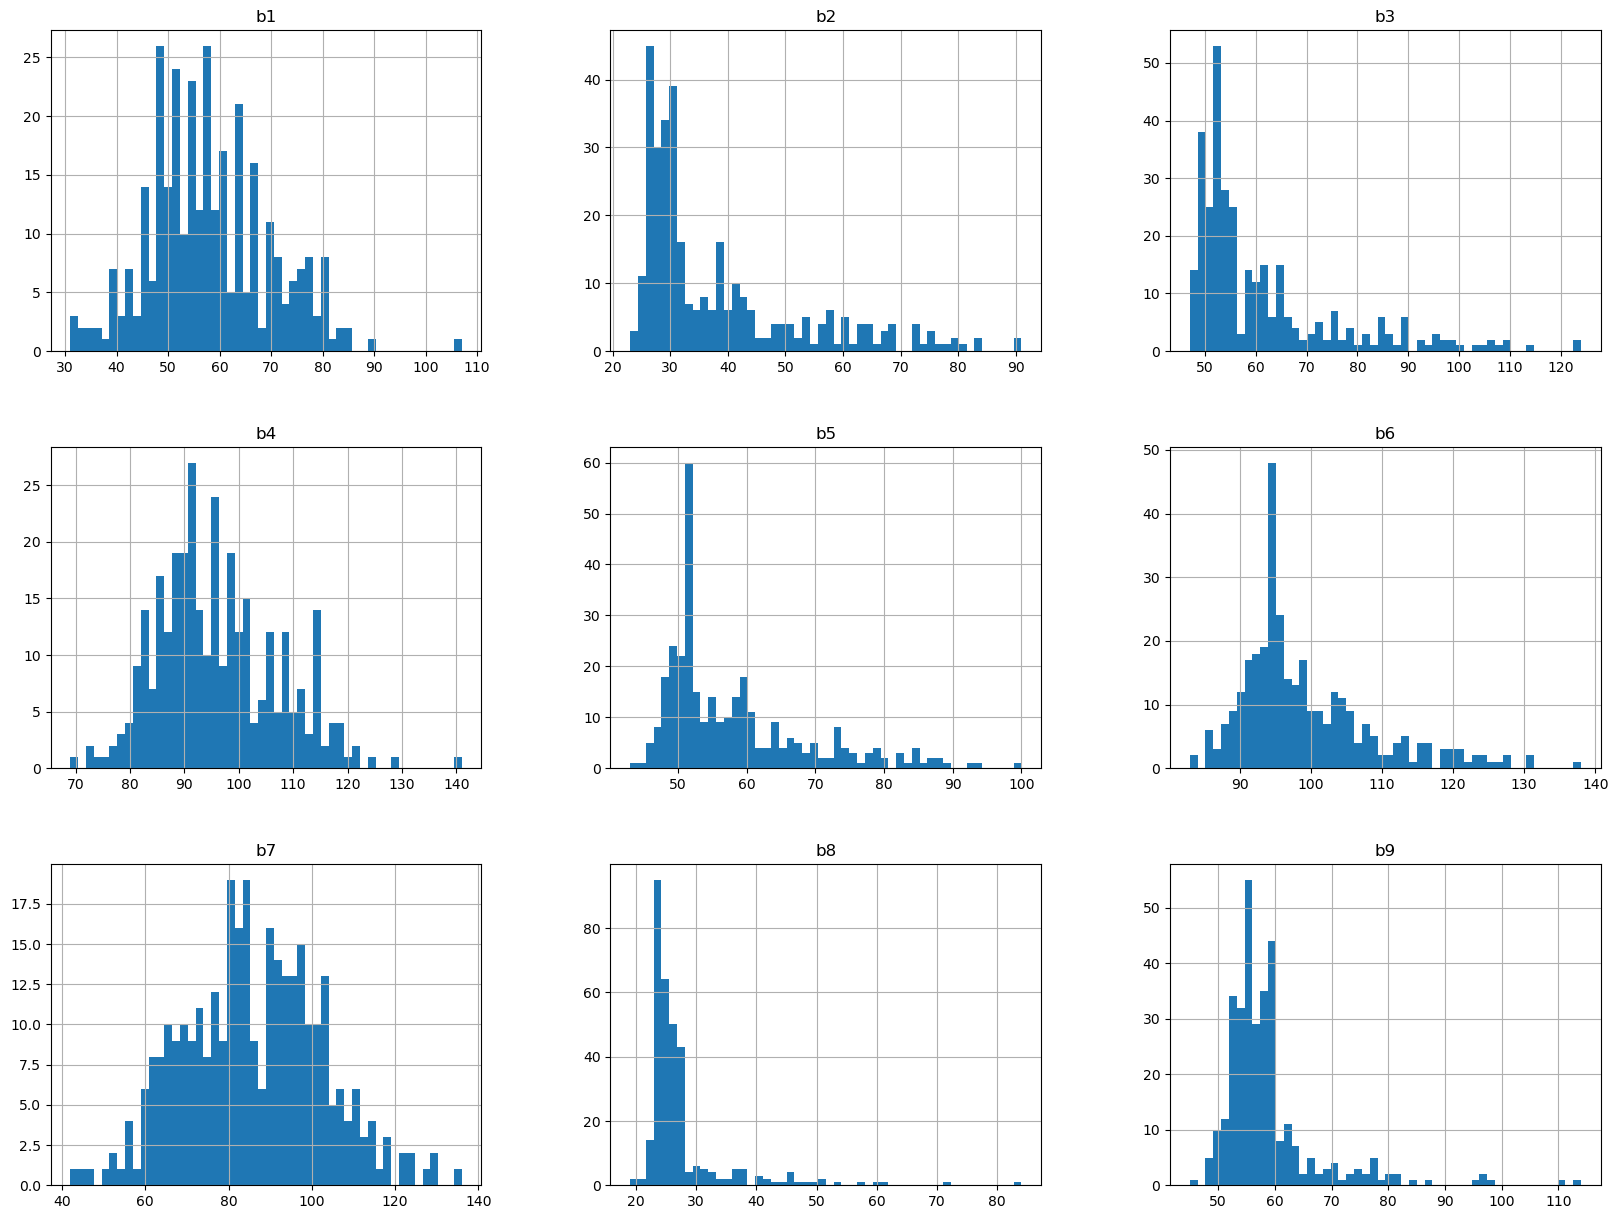

In [8]:
training.hist(bins=50, figsize=(20,15))
plt.show()

A way to visualize the features distributional differences among the different classes is with a parallel coordinate plot. Here we can see that measures of the `s` and `h` classes are lower in general, and in particular are much lower for features `b2`  and `b8`, whilst `b4`, `b6` and `b7` are generally higher. Furthermore, it appears that the variability is greater among the `d` and `o` classes, i.e., the spread between minimum and maximum values is larger.

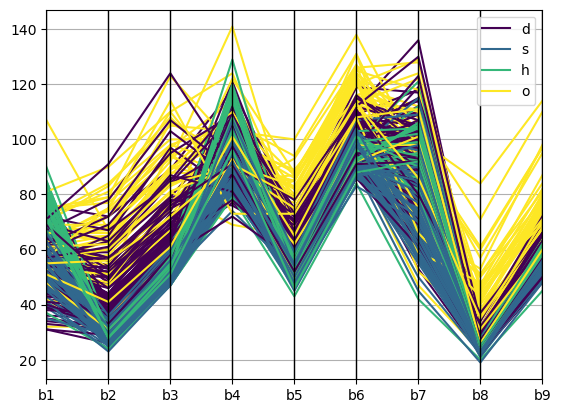

In [9]:
from pandas.plotting import parallel_coordinates 

parallel_coordinates(training, 'class', colormap=plt.get_cmap('viridis'))
plt.show()

Now that we have some idea of the distributional differences between the features let us investigate potential correlations. Scanning the correlation matrix we can see some high correlations such as `b2` with `b3` at approx. 0.97.

In [10]:
training.corr()

,b1,b2,b3,b4,b5,b6,b7,b8,b9
b1,1.000000,0.193934,0.239083,0.659619,0.064797,0.125729,0.538652,0.221787,0.373938
b2,0.193934,1.000000,0.973858,0.007348,0.856469,0.742261,0.371865,0.693000,0.639570
b3,0.239083,0.973858,1.000000,-0.000216,0.811359,0.696819,0.302484,0.687960,0.633026
b4,0.659619,0.007348,-0.000216,1.000000,-0.005669,0.239442,0.523521,0.043042,0.206517
b5,0.064797,0.856469,0.811359,-0.005669,1.000000,0.916407,0.345639,0.773810,0.721207
b6,0.125729,0.742261,0.696819,0.239442,0.916407,1.000000,0.371729,0.773242,0.769371
b7,0.538652,0.371865,0.302484,0.523521,0.345639,0.371729,1.000000,0.268426,0.431312
b8,0.221787,0.693000,0.687960,0.043042,0.773810,0.773242,0.268426,1.000000,0.951385
b9,0.373938,0.639570,0.633026,0.206517,0.721207,0.769371,0.431312,0.951385,1.000000


In ordering the correlations from greatest postivie to greatest negative, it is apparent that there are no highly negative correlated features but that there are a few very highly positive correlated features, i.e., $Corr(b2, b3) = 0.97$, $Corr(b9, b8) = 0.95$ etc.

In [11]:
training.corr().unstack().sort_values(ascending=False).drop_duplicates()[1:]

b2  b3    0.973858
b9  b8    0.951385
b5  b6    0.916407
    b2    0.856469
b3  b5    0.811359
b5  b8    0.773810
b8  b6    0.773242
b6  b9    0.769371
b2  b6    0.742261
b9  b5    0.721207
b3  b6    0.696819
b2  b8    0.693000
b3  b8    0.687960
b1  b4    0.659619
b2  b9    0.639570
b3  b9    0.633026
b1  b7    0.538652
b4  b7    0.523521
b7  b9    0.431312
b9  b1    0.373938
b2  b7    0.371865
b6  b7    0.371729
b7  b5    0.345639
    b3    0.302484
b8  b7    0.268426
b6  b4    0.239442
b1  b3    0.239083
    b8    0.221787
b9  b4    0.206517
b1  b2    0.193934
b6  b1    0.125729
b1  b5    0.064797
b4  b8    0.043042
    b2    0.007348
b3  b4   -0.000216
b5  b4   -0.005669
dtype: float64

Although the high linear correlations will, when plotted, all look similar, we can see from the two highest correlated features `(b2, b3)` and `(b9, b8)` (see below) that the correlation is stronger in the lower range of the feature values and that the `o` class is largely responsible for the dispersion at higher values.  

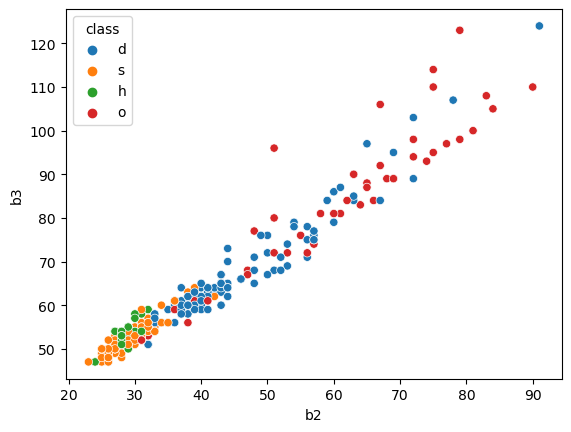

In [12]:
sns.scatterplot(data=training, x='b2', y='b3', hue="class");

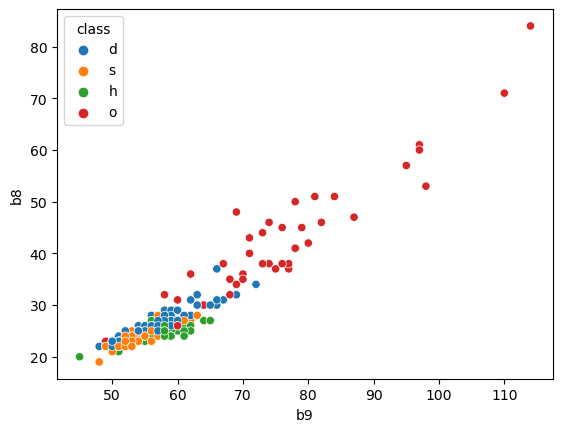

In [13]:
sns.scatterplot(data=training, x='b9', y='b8', hue="class");

### Task 4.

We now need to determine the class proportions. Here we count the number of instances for each class label.

In [14]:
training['class'].value_counts()

s    136
d    105
o     46
h     38
Name: class, dtype: int64

Inpecting the pie chart below, we see the frequency proportions for classes `d` with `s` are reasonably well balanced, i.e., approx. 32% and 42% respectively. The same can be observed for classes `o` with `h`, i.e., approx. 14% and 12% respectively. On the other hand, there is clearly a difference of frequency between classes `d` and `s` considered together with respect to classes `o` and `h`, i.e., `d` and `s` account for approx. 74% of the data, whilst `o` and `h` account for only approx. 26% of the data. It is therefore most appropriate to use classes `d` and `s` for our binary classification tasks because these classes account for the majority of the observations and are reasonbly well balanced.

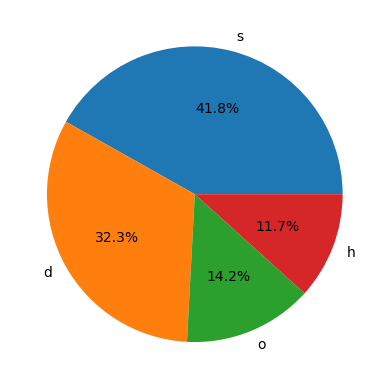

In [15]:
# Pie chart - class proportions
counts = training['class'].value_counts()
counts = counts / counts.sum()
class_labels = counts.index.values
plt.pie(list(counts), labels=list(class_labels), autopct='%1.1f%%');

### Task 5.

Now that we have completed a basic preliminary investigation of the data we must perform appropriate preprocessing and feature scaling to prepare the data for the classification models we will apply. In order to ensure that both training and testing data are preprocessed in a uniform manner (keeping in mind that scaling parameters derived from the training data must be applied to the test data) we can implement a basic function that can be called when required. In addition to the scaling and numeric transforms, the function also takes into account the need to retain only the high proportion classes `s` and `d` in the binary classification setting, and for later multiclass classification tasks, retain all classes.

In [16]:
from sklearn.preprocessing import StandardScaler

# Data preprocessing; scaling & class separation
def prepare_data(training, testing, all_classes):
    if not all_classes:
        training = training[(training['class'] == 's') | 
            (training['class'] == 'd')]
        testing = testing[(testing['class'] == 's') | 
            (testing['class'] == 'd')]
    y_train = training['class']
    X_train = training.drop('class', axis=1)
    y_test = testing['class']
    X_test = testing.drop('class', axis=1)
    std_scaler = StandardScaler().fit(X_train.to_numpy())
    X_train_std = std_scaler.transform(X_train.to_numpy())
    X_test_std = std_scaler.transform(X_test.to_numpy())
    y_train = y_train.to_numpy()
    y_test = y_test.to_numpy()
    return X_train_std, y_train, X_test_std, y_test


### Task 6.

We can now begin applying classification methods to the data. We will start with the Logistic Regression Classifier implemented in the `sklearn.linear_model` class to perform binary classification using examples from the two classes: `s` (*Sugi* forest) and `d` (*Mixed deciduous* forest). Firstly, we will call the data preparation function desribed above to take care of the transformations and class separation.

In [17]:
from sklearn.linear_model import LogisticRegression

X_train, y_train, X_test, y_test = prepare_data(
    training, testing, all_classes=False
)

### Task 7(a).

Initially, we will consider two individual features, `b1` and `b7`, for the logistic regression classifier. We can
plot the estimated probabilities and decision boundaries for the two models in order to visualize the classification of the classes (i.e., `s` and `d`), noting that the plots are likely to differ as the features have differing variance (i.e., `b1` has standard deviation approx. 11 whilst `b7` has the largest standard deviation among the features of approx. 17).

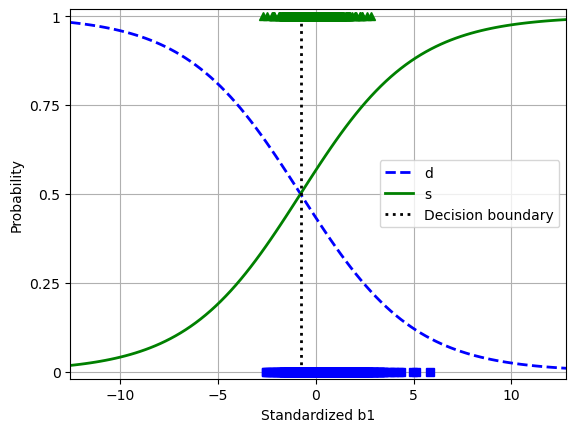

In [18]:
# Fit logistic regression model using feature b1
X_train_b1 = X_train[:,0].reshape(-1,1)
log_reg_b1 = LogisticRegression(random_state=42)
log_reg_b1.fit(X_train_b1, y_train)

# Extract probabilities; decision boundary
L = X_train_b1.min() - 10
U = X_train_b1.max() + 10
X_new = np.linspace(L, U, 100).reshape(-1, 1)
y_proba = log_reg_b1.predict_proba(X_new)
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]

# Plot probabilities; decision boundary; projected points
plt.plot(X_new, y_proba[:, 0], "b--", linewidth=2, label="d")
plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="s")
plt.plot([decision_boundary, decision_boundary], [0, 1], "k:",
         linewidth=2, label="Decision boundary")
plt.plot(X_train[y_train == 'd'], y_train[y_train == 'd'], "bs")
plt.plot(X_train[y_train == 's'], y_train[y_train == 's'], "g^")
plt.xlabel("Standardized b1")
plt.ylabel("Probability")
plt.legend(loc="center right")
plt.axis([L, U, -0.02, 1.02])
plt.yticks([0, 0.25, 0.5, 0.75, 1], [0, 0.25, 0.5, 0.75, 1])
plt.grid()
plt.show()

In [19]:
# Feature b1 decision boundary
decision_boundary

-0.7662475324124323

Inspecting the plot (above) and associated decision boundary, we see that as the points of class `d` (projected onto the x-axis shown in blue) become more sparse in the positive direction, the decision probability falls. On the other hand, as the density of the points of class `s` increases, the probability rises. Unfortunately, there is a degree of ambiguity when considering a small margin around the decision boundary where it is not clear which points (i.e, which class) are 'more likely'. Now we shall construct the same plot for feature `b7` (below), noting that the larger variance of this feature is likely the reason the plot is more difficult to interpret.

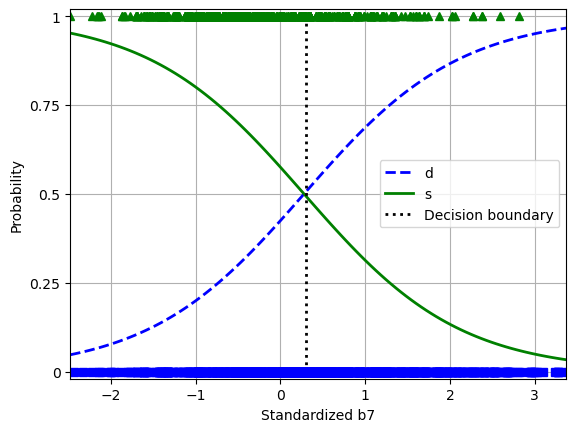

In [20]:
# Fit logistic regression model using feature b7
X_train_b2 = X_train[:,6].reshape(-1,1)
log_reg_b2 = LogisticRegression(random_state=42)
log_reg_b2.fit(X_train_b2, y_train)

# Extract probabilities; decision boundary
L = X_train_b2.min() 
U = X_train_b2.max() 
X_new = np.linspace(L, U, 100).reshape(-1, 1) 
y_proba = log_reg_b2.predict_proba(X_new)
decision_boundary = X_new[y_proba[:, 0] >= 0.5][0, 0]

# Plot probabilities; decision boundary; projected points
plt.plot(X_new, y_proba[:, 0], "b--", linewidth=2, label="d")
plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="s")
plt.plot([decision_boundary, decision_boundary], [0, 1], "k:",
         linewidth=2, label="Decision boundary")
plt.plot(X_train[y_train == 'd'], y_train[y_train == 'd'], "bs")
plt.plot(X_train[y_train == 's'], y_train[y_train == 's'], "g^")
plt.xlabel("Standardized b7")
plt.ylabel("Probability")
plt.legend(loc="center right")
plt.axis([L, U, -0.02, 1.02])
plt.yticks([0, 0.25, 0.5, 0.75, 1], [0, 0.25, 0.5, 0.75, 1])
plt.grid()
plt.show()

In [21]:
# Feature b7 decision boundary
decision_boundary

0.2980936833085899

### Task 7(b).

Now we will plot the estimated probabilities and decision boundary for a model considering all features. We will randomly sample 10 instances of the testing set to add to the plot in order to determine if the classifier makes a right or wrong decision regarding the decision boundary threshold of 50%.

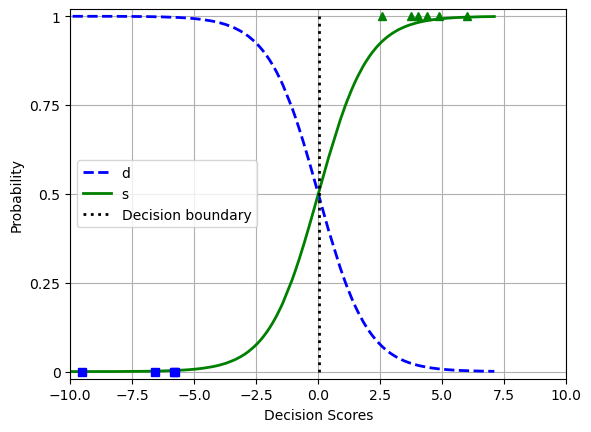

In [22]:
# Prepare a random sample from test data
test_sample = testing[(testing['class'] == 's') | 
    (testing['class'] == 'd')].sample(10, axis=0, random_state=42)
_, _, X_test_sample, y_test_sample = prepare_data(
    training, test_sample, all_classes=False
)

# Fit logistic regression model using all features
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

# Extract probabilities; decision scores & boundary
X_train_scores = log_reg.decision_function(X_train).flatten()
X_test_sample_scores = log_reg.decision_function(X_test_sample).flatten()
idx = np.argsort(X_train_scores)
X_new = X_train
y_proba = log_reg.predict_proba(X_new)
decision_boundary = X_new[y_proba[idx, 1] >= 0.5][0, 0]

# Plot probabilities; decision boundary; projected points
plt.clf()
plt.plot(X_train_scores[idx], y_proba[idx, 0], "b--", linewidth=2, label="d")
plt.plot(X_train_scores[idx], y_proba[idx, 1], "g-", linewidth=2, label="s")
plt.plot([decision_boundary, decision_boundary], [0, 1], "k:",
         linewidth=2, label="Decision boundary")
plt.plot(X_test_sample_scores[y_test_sample == 'd'],
         y_test_sample[y_test_sample == 'd'], "bs")
plt.plot(X_test_sample_scores[y_test_sample == 's'],
         y_test_sample[y_test_sample == 's'], "g^")
plt.xlabel("Decision Scores")
plt.ylabel("Probability")
plt.legend(loc="center left")
plt.axis([-10, 10, -0.02, 1.02])
plt.yticks([0, 0.25, 0.5, 0.75, 1], [0, 0.25, 0.5, 0.75, 1])
plt.grid()
plt.show()

It is clear from the plot (above) that the logistic regression model using all features correctly classifies these 10 instances randomly sampled from the testing data. The points in class `d` (blue) are far in the negative direction from the dedision boundary and have high probability whilst the points in class `s` are far from the decision boundary in the positive direction and have high probaility. These observations make clear the apparent difference in performance of the classifier when using all features as opposed to constraining the classifier to a single feature (as in previous plots) - the former appears to be much better at the task. 

### Task 8.

To better evaluate the perfomance of our logistic regression classifier we can plot a graph of precision versus recall and inspect how various decision thresholds may affect the outcome. We will use cross validation to determine a reliable measure of this performance.

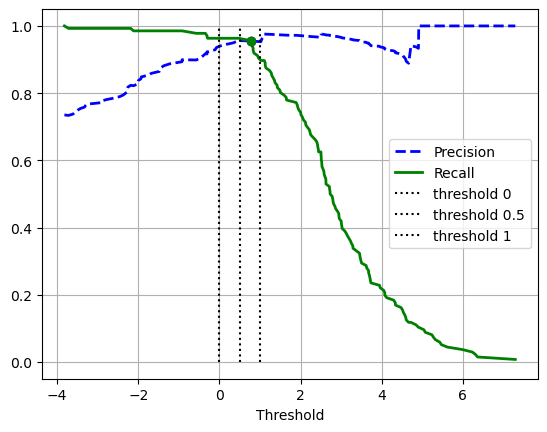

In [23]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve

# Extract scores via (k = 3) fold cross-validation
y_scores = cross_val_predict(
    log_reg, X_train, y_train, cv=3, method="decision_function"
)
# Extract performance metrics; set various thresholds
precisions, recalls, thresholds = precision_recall_curve(y_train == 's', y_scores)
threshold_0 = 0
threshold_ = 0.5
threshold_1 = 1

# Plot precision & recall curves
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2) 
plt.vlines(threshold_0, 0, 1.0, "k", "dotted", label="threshold 0")
plt.vlines(threshold_, 0, 1.0, "k", "dotted", label="threshold 0.5")
plt.vlines(threshold_1, 0, 1.0, "k", "dotted", label="threshold 1")
idx = (thresholds >= threshold_).argmax()
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")
plt.show()

Examining the precision and recall curves (above) we can see that there is an optimal threshold score lying in the interval $[0.5, 1]$ where thresholds outside of this interval result in a gradual decline in precision (negative direction) and a rapid decline in recall (positive direction). Therefore, we estimate that the optimal threshold is approximately 0.75. Now we can see where this threshold score of 0.75 is placed when considering precision as a function of recall. 

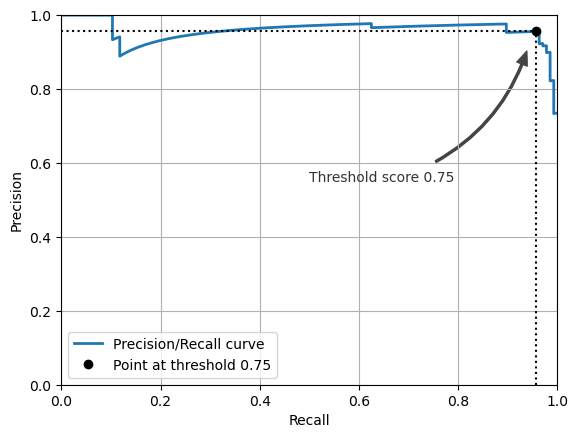

In [24]:
import matplotlib.patches as patches  

# Set threshold
threshold = .75

# Plot precision as function of recall; project threshold score
plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")
plt.plot([recalls[idx], recalls[idx]], [0., precisions[idx]], "k:")
plt.plot([0.0, recalls[idx]], [precisions[idx], precisions[idx]], "k:")
plt.plot([recalls[idx]], [precisions[idx]], "ko",
         label="Point at threshold 0.75")
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.75, 0.60), (0.94, 0.91),
    connectionstyle="arc3,rad=.2",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.5, 0.55, 
    "Threshold score 0.75",
    color="#333333")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")
plt.show()

It appears (above plot) that the chosen threshold of 0.75 strikes an appropriate balance when considering the tradeoff between precision and recall.

### Task 9.

Having fitted and analysed the logistic regression classifier we will now use the k-nearest neighbours (k-NN) algorithm for the same binary classification task, trying different values of the parameter k - seeing how accuracy changes with respect to k.

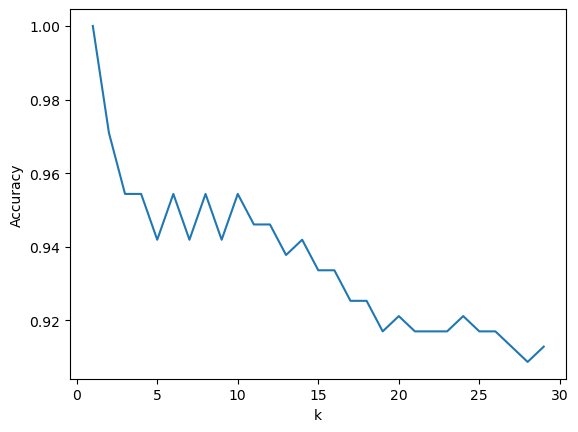

In [25]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Fit KNN classifier for various values of k; plot accuracy
k_range = list(range(1, 30))
scores = []
for i in k_range:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_train)
    scores.append(accuracy_score(y_train, y_pred))
plt.plot(k_range, scores)
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.show()

We know that a k value of 1 is overfit and therefore, by inpsecting (above plot) the decline and subsequent stabilization of accuracy between k values of approx. 2 to 10 that the optimal value lies in this range. To determine a definitve k value we can perform a parameter grid search. The search results in an optimal (in terms of scoring accuracy) k value of 8 (see below).

In [26]:
# Perform grid search
knn = KNeighborsClassifier()
param_grid = dict(n_neighbors=list(range(1, 16)))
knn_grid = GridSearchCV(
    knn, param_grid, cv=10, scoring='accuracy',
    return_train_score=False, verbose=0
)

# Extract best parameter value
grid_search = knn_grid.fit(X_train, y_train)
grid_search.best_score_
grid_search.best_estimator_.get_params()['n_neighbors']

8

In [27]:
# Choose k = 8
knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=8)

### Task 10.

We are now able to compare the performance of the two classifiers (Logistic Regression and k-NN) and give a brief discussion of the experimental results. To inform our comparison we show the confusion matrices, ROC curves and accuracies of the two classifiers for the testing set. In the case of the logistic regression classifier, we will utilize the threshold value we discovered previously.

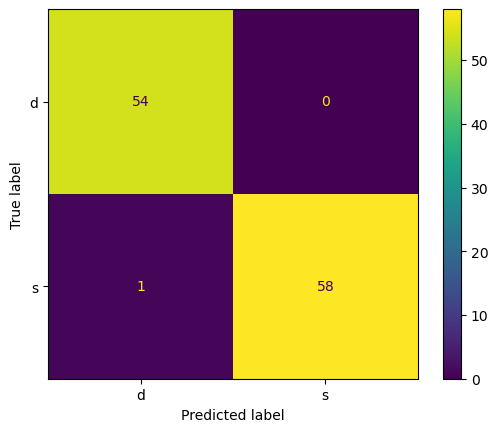

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score

# Confusion matrix (test data) - logistic regression w. decision threshold: 0.75
log_reg_pred = (log_reg.decision_function(X_test) >= threshold).astype(int)
log_reg_pred = np.where(log_reg_pred, log_reg.classes_[1], log_reg.classes_[0])
conf_mtx = confusion_matrix(y_test, log_reg_pred, labels=log_reg.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mtx, display_labels=log_reg.classes_);
disp.plot();
plt.show()

In [29]:
# Accuracy - logistic regression w. decision threshold: 0.75
sum(log_reg_pred == y_test) / len(y_test)

0.9911504424778761

The classification results (above) for test data using the logistic regression model with decision boundary threshold of 0.75 are very accurate (i.e., only one incorrect classifcation ressulting in 0.99 accuracy). Turning now to the Knn classifier.

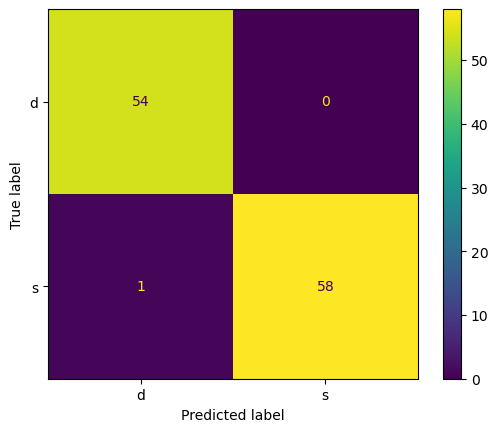

In [30]:
# Confusion matrix (test data) - knn w. k = 8
knn_pred = knn.predict(X_test)
conf_mtx = confusion_matrix(y_test, knn_pred, labels=knn.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mtx, display_labels=knn.classes_)
disp.plot();
plt.show()

In [31]:
# Accuracy - knn w. k = 8
sum(knn_pred == y_test) / len(y_test)

0.9911504424778761

The classification results (above) for test data using the knn model w. k = 8 are also very accurate (i.e., only one incorrect classifcation ressulting in 0.99 accuracy). Indeed, the two classifiers perform identically on the test data. In the context of binary classification, these results (see ROC below) are anomalous. It is very unlikely that given a larger set of testing data (potentially greater variability) that the performance of these classifiers would not decline significantly. Therefore, we should take a cautious stance with respect to the indicative high performance of these classifiers.

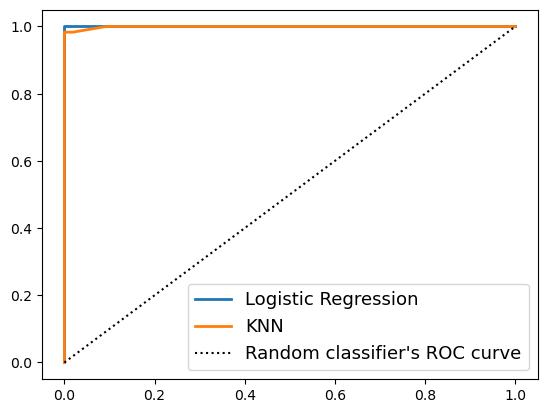

In [32]:
# ROC curve - logistic regression w. decision threshold: 0.75
# ROC curve - knn w. k = 8
log_reg_proba = log_reg.predict_proba(X_test)
log_reg_fpr, log_reg_tpr, log_reg_thresholds = roc_curve(y_test == 's', log_reg_proba[:,1])
knn_proba = knn.predict_proba(X_test)
knn_fpr, knn_tpr, knn_thresholds = roc_curve(y_test == 's', knn_proba[:,1])
plt.plot(log_reg_fpr, log_reg_tpr, linewidth=2, label="Logistic Regression")
plt.plot(knn_fpr, knn_tpr, linewidth=2, label="KNN")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.legend(loc="lower right", fontsize=13)
plt.show()

### Task 11.

We will now use 3-fold cross-validation and discuss the generalisation capacity of the two classifiers. We begin with the logistic regression model.

In [33]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.dummy import DummyClassifier

In [34]:
# Logistic regression cv predictions - training set
cross_val_score(log_reg, X_train, y_train, cv=3, scoring="accuracy")

array([0.92592593, 0.9625    , 0.95      ])

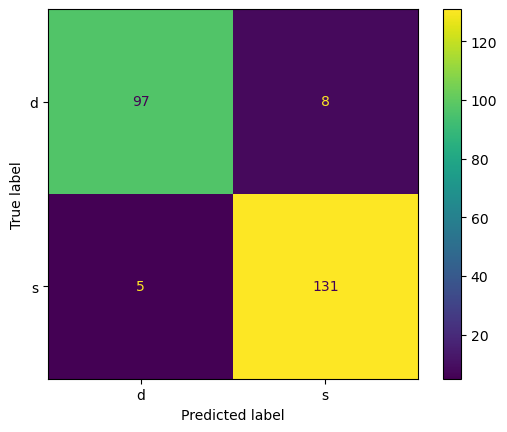

In [35]:
# Confusion matrix logistic regression - training set
conf_mtx = confusion_matrix(
    y_train,
    cross_val_predict(log_reg, X_train, y_train, cv=3)
)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mtx, display_labels=log_reg.classes_)
disp.plot();
plt.show()

In [36]:
# Logistic regression cv predictions - test set
cross_val_score(log_reg, X_test, y_test, cv=3, scoring="accuracy")

array([0.97368421, 0.97368421, 1.        ])

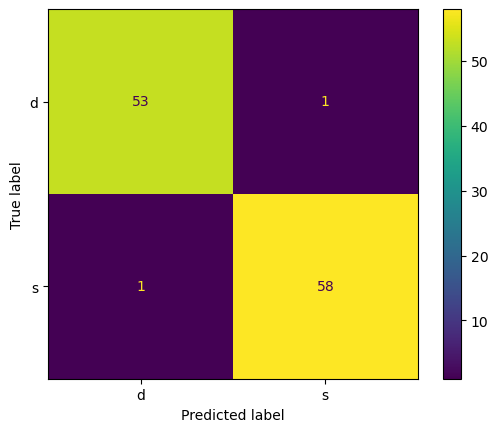

In [37]:
# Confusion matrix logsitic regression - test set
conf_mtx = confusion_matrix(
    y_test,
    cross_val_predict(log_reg, X_test, y_test, cv=3)
)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mtx, display_labels=log_reg.classes_)
disp.plot();
plt.show()

From the results (above) for the logistic regression model, we see that the classifier generalizes exceptionally well (i.e., performance improves on the test set over the training). Now we do the same for the knn model.

In [38]:
# Knn cv predictions - training set
cross_val_score(knn, X_train, y_train, cv=3, scoring="accuracy")

array([0.90123457, 0.9625    , 0.925     ])

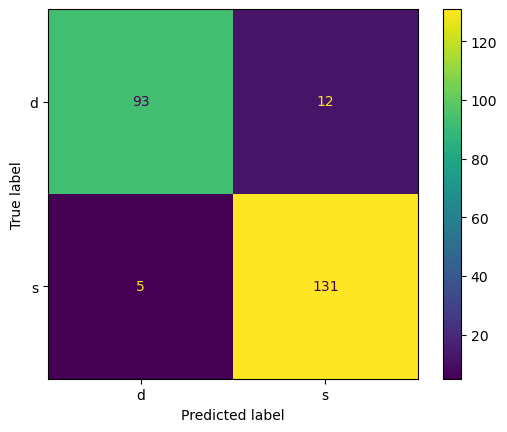

In [39]:
# Confusion matrix knn - training set
conf_mtx = confusion_matrix(
    y_train,
    cross_val_predict(knn, X_train, y_train, cv=3)
)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mtx, display_labels=knn.classes_)
disp.plot();
plt.show()

In [40]:
# Knn cv predictions - test set
cross_val_score(knn, X_test, y_test, cv=3, scoring="accuracy")

array([0.97368421, 0.97368421, 1.        ])

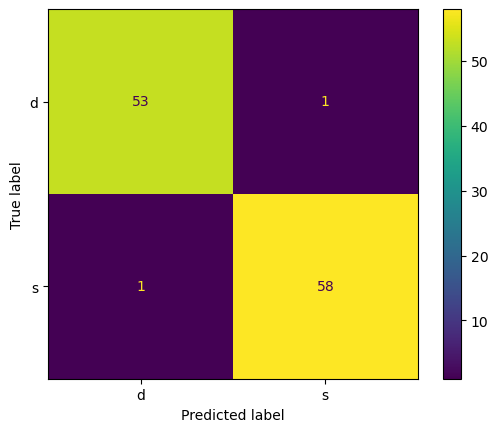

In [41]:
# Confusion matrix knn - test set
conf_mtx = confusion_matrix(
    y_test,
    cross_val_predict(knn, X_test, y_test, cv=3)
)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mtx, display_labels=knn.classes_)
disp.plot();
plt.show()

Again, generalizability is very strong in the knn model. However, using cross validation (k = 3) we can see that the classifiers have both made an additional missclassification (see above confusion matrices) on the test set over the models that were evaluated previously without cross validataion. That aside, the classifiers are still performing identically on the test set. In addition, this performance remains anomalously accurate. Because of these results, we should remain dubious that the classifiers performance would not significantly decline when evaluated on larger testing data - perhaps representing greater variability. We shall now turn our attention to multiclass classification using all classes `(s, d, o, h)` in the “Forest type mapping Data Set”.

### Multiclass classification Tasks

### Task 12.

To begin the next stage of our classification we will use a Support Vector Machine Classifier (SVC) implemented in the `sklearn.svm.SVC` class to perform multiclass classification using the one-versus-one strategy. Additionally, we can use a grid search and 3 fold cross validation to find the optimal combination of hyperparameter values that maximise the classification accuracy. Firstly, we will prepare the data for multiclass classification using the data preprocessing funtion defined earlier, then we can define our hyperparameter values for grid search and subsequently fit the training data to resulting the SVC one-versus-one classifier.

In [42]:
from sklearn.svm import SVC
from sklearn.multiclass import OneVsOneClassifier
from sklearn.metrics import accuracy_score, classification_report

# Prepare data for multiclass classification
X_train, y_train, X_test, y_test = prepare_data(training, testing, all_classes=True)

# Set hyperparameter grid
parameters = {
    "estimator__C": [1,10,100,1000],
    "estimator__gamma": [0.01, 0.1, 1, 10],
    "estimator__kernel": ["poly","rbf"],
    "estimator__degree":[1,2,3,4],
}

# Fit one-versus-one SVC grid model to training data
svc_ovo = OneVsOneClassifier(SVC())
svc_ovo_grid = GridSearchCV(svc_ovo, param_grid=parameters, cv=3)
svc_ovo_grid.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=OneVsOneClassifier(estimator=SVC()),
             param_grid={'estimator__C': [1, 10, 100, 1000],
                         'estimator__degree': [1, 2, 3, 4],
                         'estimator__gamma': [0.01, 0.1, 1, 10],
                         'estimator__kernel': ['poly', 'rbf']})

The hyperparameter grid (above) utilizes a combination of parameters to tune the model with cross validation. Here we have chosen to specify the following estimators:
- `C` specifies the degree of model regularization, i.e., it represents the trade off between misclassification of training examples against the simplicity of the decision surface. Decreasing `C` corresponds to more regularization.
- `gamma` specifies how far the influence of a single training example reaches, with low values meaning ‘far’ and high values meaning ‘close’. The gamma parameters can be seen as the inverse of the radius of influence of samples selected by the model as support vectors.
- `degree` specifies the order of the kernel function.
- `kernel` specifies the type of kernel to use, i.e., `poly` (polynomial) or `rbf` (Radial Basis Function).

In [43]:
# Optimal hyperparameter combination
svc_ovo_grid.best_params_

{'estimator__C': 1,
 'estimator__degree': 1,
 'estimator__gamma': 0.1,
 'estimator__kernel': 'rbf'}

In [44]:
# Best score on training data
svc_ovo_grid.best_score_

0.8893419413297089

Examining the results (above) we can see that the hyperparameter grid search resulted in an optimal SVC classifier with an `rbf` (Radial Basis Function) kernel with (`C`, `gamma`) set to (`1`, `0.1`). With these hyperparameter settings the resultant model accuracy when evaluated on the training set is approx. 0.89. Finally, it is clear from the confusion matrix (below) that the classifier performs best on classes `s` and `d`. 

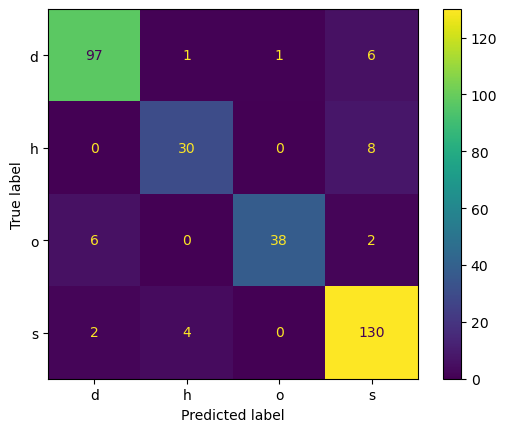

In [45]:
# SVC one-versus-one confusion matrix
conf_mtx = confusion_matrix(y_train, svc_ovo_grid.predict(X_train))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mtx, display_labels=svc_ovo_grid.classes_)
disp.plot();
plt.show()

### Task 13.

Now we shall perform Softmax Regression and the k-NN algorithm (with various values of k) on the same classification tasks before commenting about the results of the three techniques (SVM, Softmax Regression and k-NN). We will begin with Softmax Regression.

In [46]:
# Fit softmax regression model; calculate accuracy
softmax_reg = LogisticRegression(multi_class = 'multinomial', solver = 'lbfgs')
softmax_reg.fit(X_train, y_train)
accuracy_score(y_train, softmax_reg.predict(X_train))

0.9046153846153846

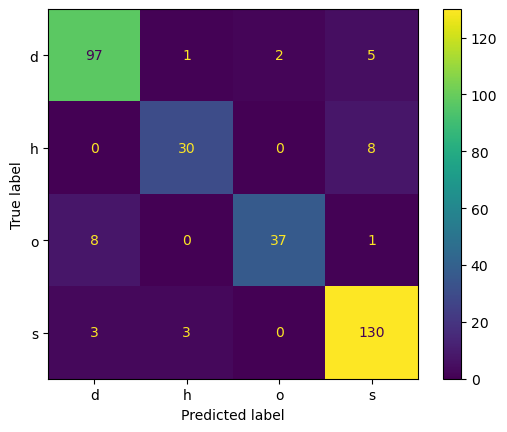

In [47]:
# Softmax regression confusion matrix
conf_mtx = confusion_matrix(y_train, softmax_reg.predict(X_train))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mtx, display_labels=softmax_reg.classes_)
disp.plot();
plt.show()

The performance (see above) of Softmax Regression is nearly identical to that of the SVC classifier. Next we will evaluate the K-nn model where we can begin by plotting accuracy for various values of k.

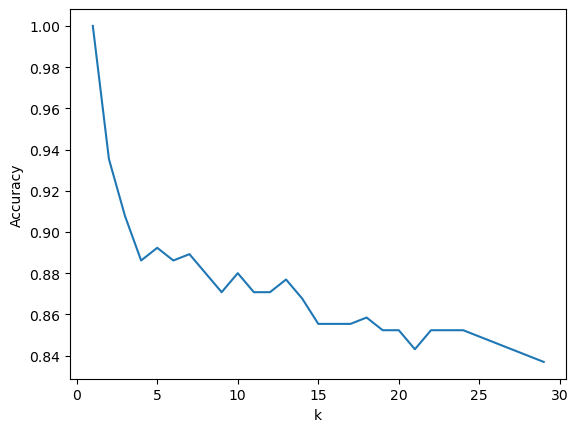

In [48]:
# Plot accuracy for various values of k
k_range = list(range(1, 30))
scores = []
for i in k_range:
    knn_multi = KNeighborsClassifier(n_neighbors=i)
    knn_multi.fit(X_train, y_train)
    y_pred = knn_multi.predict(X_train)
    scores.append(accuracy_score(y_train, y_pred))
plt.plot(k_range, scores)
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.show()

Here again, as was the case in the two class classification setting, the accuracy declines rapidly from k = 1 (overfit) and subsequently decreases in an oscillating fashion. We can surmise that the optimal value for k lies somewhere in the interval approx. $[2, 8]$. To better determine this value we can perform a grid search in a similar way as was the case for the SVC classifier. 

In [49]:
# Find best k w. grid search
knn_multi = KNeighborsClassifier()
param_grid = dict(n_neighbors=list(range(1, 16)))
knn_grid = GridSearchCV(
    knn_multi, param_grid, cv=10, scoring='accuracy',
    return_train_score=False, verbose=0
)
knn_grid_search = knn_grid.fit(X_train, y_train)
knn_grid_search.best_estimator_.get_params()['n_neighbors']

6

According to the the grid search, the best hyperparameter value for k is 6 (see above). With this value, the corresponding accuracy is approx. 0.87 (see below). In addition, the confusion matrix (below) is again very similar to the SVC classifier and the Softmax Regression classifier (i.e., making similar missclassifications and performing well on classes `s` and `d`). 

In [50]:
knn_grid_search.best_score_

0.8707386363636364

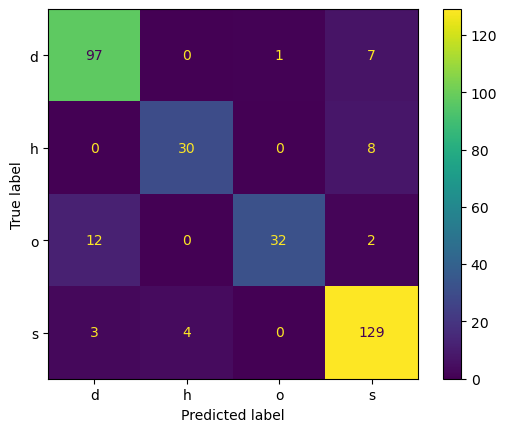

In [51]:
# Knn w. k = 6 confusion matrix
conf_mtx = confusion_matrix(y_train, knn_grid_search.predict(X_train))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mtx, display_labels=knn_grid_search.classes_)
disp.plot();
plt.show()

Finally, we present a report (see below) of the important performance metrics for each of the classifiers we considered above - evaluated on the test set. We see again that the classifiers all perform very similarly, indeed almost identically. If we were to determine the best model based on the f1-score for example, the knn model (k = 6) would be superior to the other classifiers (i.e., f1-score 0.93 for knn; f1-score 0.92 for SVC; f1-score 0.91 for Softmax Regression). But, as stated earlier in regard to the binary classification setting, because of these results, we should remain dubious that the classifiers performance would not significantly decline when evaluated on larger testing data (perhaps representing greater variability) and we should seek to acquire more data and further investigate model performance.

In [52]:
print(classification_report(y_test, svc_ovo_grid.predict(X_test)))

              precision    recall  f1-score   support

           d       0.93      0.98      0.95        54
           h       0.95      0.81      0.88        48
           o       0.97      0.92      0.94        37
           s       0.86      0.95      0.90        59

    accuracy                           0.92       198
   macro avg       0.93      0.92      0.92       198
weighted avg       0.92      0.92      0.92       198



In [53]:
print(classification_report(y_test, softmax_reg.predict(X_test)))

              precision    recall  f1-score   support

           d       0.95      0.98      0.96        54
           h       0.95      0.79      0.86        48
           o       0.94      0.92      0.93        37
           s       0.85      0.95      0.90        59

    accuracy                           0.91       198
   macro avg       0.92      0.91      0.91       198
weighted avg       0.92      0.91      0.91       198



In [54]:
print(classification_report(y_test, knn_grid_search.predict(X_test)))

              precision    recall  f1-score   support

           d       0.91      0.98      0.95        54
           h       0.95      0.88      0.91        48
           o       0.97      0.89      0.93        37
           s       0.90      0.95      0.93        59

    accuracy                           0.93       198
   macro avg       0.94      0.92      0.93       198
weighted avg       0.93      0.93      0.93       198



## Part 2 - Implementing the K-Nearest Neighbours (k-NN) Algorithm for Regression

### Task 1.

Here we apply the k-NN regression algorithm to the California Housing Prices dataset described in the book *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow 2nd ed. (2019) by Aurélien Géron* to predict median house values of certain districts in California. Firstly, we load the data-set and then randomly split the data into a training set (80%) and a test set (20%).

N.B. We will evaluate the root mean square error performance metric (RMSE) in the next section after having performed necessary data preprocessing.

In [55]:
from pathlib import Path
import tarfile
import urllib.request

# Fetch housing data
def load_housing_data():
    tarball_path = Path("./housing.tgz")
    if not tarball_path.is_file():
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall()
    return pd.read_csv(Path("./housing/housing.csv"))

housing = load_housing_data()

# RANDOMLY split the data into train/test
from sklearn.model_selection import train_test_split
training, testing = train_test_split(housing, test_size=0.2, random_state=42)

# Features & target
X_train = training.drop("median_house_value", axis=1)
y_train = training["median_house_value"].copy()
X_test = testing.drop("median_house_value", axis=1)
y_test = testing["median_house_value"].copy()

# N.B. root mean square error calculations evaluated in next section

### Task 2.

Now we shall perform the necessary data preprocessing (i.e., scaling, categorical encoding etc) of the dataset to form appropriate feature vectors. Rather than disregard those columns that contain text (i.e., `ocean_proximity`), we can one-hot encode them as part of our preprocessing pipeline. Additionally, we will need to impute some missing values and perform a scaling transform so that the fitted model is not biased by some features that have large magnitude.

In [56]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsRegressor 
from sklearn.metrics import mean_squared_error

# Rather than removing categorical (i.e., text) columns
# we will encode the categories as part of preprocessing

# Data preparation/preprocessing
# Median impute missing values; standardize
num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy="median")),
        ('std_scaler', StandardScaler()),
])
# One hot encode categorical feature
full_pipeline = ColumnTransformer([
        ("num", num_pipeline, list(housing.columns[:8])),
        ("cat", OneHotEncoder(), ["ocean_proximity"]),
])
# Fit training data; transform test data
X_train = full_pipeline.fit_transform(X_train)
X_test = full_pipeline.transform(X_test)

# Dimensions
X_train.shape

(16512, 13)

We see that after preprocessing we end up with 16512 observations in the training set consisting of 13 features. Now that the data are prepared we can fit the Knn Regression model to these data and evaluate the performance by calculating the root mean square error (RMSE) on the test data.

In [57]:
# Fit knn regression model weights = uniform
knn_reg = KNeighborsRegressor()
knn_reg.fit(X_train, y_train)

# RMSE - test data
mean_squared_error(y_test, knn_reg.predict(X_test), squared=False)

63140.13648452379

The fitted knn regression model (with default weights parameter set to `uniform` - equivalent to setting $wi = 1/k ∀i$) evaluated on the training data (see above) produces a RMSE of approx. $\$63140.00$.

### Task 3.

We can now also evaluate the Knn regression model by setting the parameter weights to `distance` (this is equivalent to setting $wi = 1/(d(X(i), Xtest) + ε)$). We can then compare the root mean squared errors (RMSEs) of the predictions for each of the parameter settings (`uniform` and `distance`).

In [58]:
# Fit knn regression model weights = distance
knn_reg = KNeighborsRegressor(weights='distance')
knn_reg.fit(X_train, y_train)

# RMSE - test data
mean_squared_error(y_test, knn_reg.predict(X_test), squared=False)

62622.09198465588

We observe similar performance (see above) with a RMSE of approx. $\$62622.00$. Given that the mean for the value we are trying to predict (i.e., `median_house_value`) is approx. $\$206855.00$ we should not consider the magnitude of the RMSE as small. Indeed, the error is approx. $30\%$ of the mean value of the `median_house_value`. In order to potentially improve on these models we can perform a grid search with cross validation to determine the optimal k value.

In [59]:
# Find best k w. grid search
param_grid = dict(n_neighbors=list(range(1, 32)))
knn_reg = KNeighborsRegressor(weights='distance')
knn_reg_grid = GridSearchCV(knn_reg, param_grid, cv=3)
knn_reg_grid.fit(X_train, y_train)
knn_reg_grid.best_params_

{'n_neighbors': 11}

In [60]:
# RMSE - test data
mean_squared_error(y_test, knn_reg_grid.predict(X_test), squared=False)

60869.28342767864

Inspecting the results from the grid search (above) we see that the optimal value for k is 11 and that using this parameter value has a marginal improvement on the RMSE, i.e., from a previous value of approx. $\$62622.00$ to the slightly better value of approx. $\$60869.00$. Unfortunately, this is still an error ratio of $29\%$ of the mean of the `median_house_value` - a very marginal imporvement indeed. With these observations in mind, it is likely necessary that we acquire more data and further evaluate model performance on those data. 